# DeGroot Baseline

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

In [2]:
ROOT = Path('/home/sammli/llm-network')
CLEAN = ROOT / 'modeling' / 'cleaned_data'
PAIR_DIR = ROOT / 'tests' / 'single_shot_tests' / 'data' / 'stance_converted'
RUN_DIRS = sorted([p for p in CLEAN.glob('run_*') if p.is_dir()])
assert RUN_DIRS, f'No run_* folders in {CLEAN}'

PARAMS = {
    'alpha_grid': [0.2, 0.4, 0.6, 0.8],
    'basis_grid': ['linear', 'linear_abs', 'quadratic', 'quadratic_abs'],
    'ridge_alphas': [0.0, 0.1, 1.0, 10.0],
    'predictor_noise_bins': 6,
    'predictor_rng_seed': 0,
}

print('Pure baseline mode: DeGroot update uses only alpha and neighbor opinions on discrete time slices.')


def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def numeric_agent_key(agent_id: str):
    if isinstance(agent_id, str) and agent_id.startswith('agent_'):
        tail = agent_id.split('_')[-1]
        if tail.isdigit():
            return int(tail)
    return 10**9


def parse_agent_id(v):
    if isinstance(v, str) and v.startswith('agent_'):
        return v
    if isinstance(v, int):
        return f'agent_{v}'
    return None


def get_graph_adjacency(graph):
    if isinstance(graph, dict) and 'edges' in graph:
        adj = defaultdict(list)
        for src, dst in graph.get('edges', []):
            s = parse_agent_id(src)
            d = parse_agent_id(dst)
            if s and d:
                adj[s].append(d)
        return dict(adj)
    if isinstance(graph, dict):
        return {k: list(v) for k, v in graph.items() if isinstance(v, list)}
    return {}


def to_unit_interval(x):
    x = np.asarray(x, dtype=float)
    return np.clip((x + 1.0) / 2.0, 0.0, 1.0)


def from_unit_interval(z):
    z = np.asarray(z, dtype=float)
    return np.clip(2.0 * z - 1.0, -1.0, 1.0)


def latest_pair_csv() -> Path:
    candidates = sorted(PAIR_DIR.glob('cleaned_pairs_*.csv'), key=lambda p: p.stat().st_mtime)
    assert candidates, f'No cleaned_pairs_*.csv files found in {PAIR_DIR}'
    return candidates[-1]


def load_first_post_pairs(pair_csv: Path) -> pd.DataFrame:
    pair_df = pd.read_csv(pair_csv)
    for col in ['input_stance_score', 'output_stance_score']:
        pair_df[col] = pd.to_numeric(pair_df[col], errors='coerce')
    pair_df = pair_df.dropna(subset=['input_stance_score', 'output_stance_score']).copy()
    return pair_df


def make_seed_basis(seed_unit: np.ndarray, basis_name: str) -> np.ndarray:
    s = np.asarray(seed_unit, dtype=float).reshape(-1)
    if basis_name == 'linear':
        return np.column_stack([s])
    if basis_name == 'linear_abs':
        return np.column_stack([s, np.abs(s)])
    if basis_name == 'quadratic':
        return np.column_stack([s, s**2])
    if basis_name == 'quadratic_abs':
        return np.column_stack([s, np.abs(s), s**2, np.sign(s - 0.5)])
    raise ValueError(f'Unknown basis: {basis_name}')


def make_regressor(alpha: float):
    if alpha <= 0.0:
        return LinearRegression()
    return Ridge(alpha=alpha)


def fit_noise_profile(seed_unit_train: np.ndarray, residual_train: np.ndarray, n_bins: int = 6, min_sigma: float = 0.03):
    global_sigma = float(np.std(residual_train, ddof=1)) if len(residual_train) > 1 else min_sigma
    global_sigma = max(global_sigma, min_sigma)

    edges = np.quantile(seed_unit_train, np.linspace(0.0, 1.0, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return {'centers': np.array([float(np.mean(seed_unit_train))]), 'sigmas': np.array([global_sigma]), 'min_sigma': min_sigma}

    centers = []
    sigmas = []
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        if i == len(edges) - 2:
            mask = (seed_unit_train >= lo) & (seed_unit_train <= hi)
        else:
            mask = (seed_unit_train >= lo) & (seed_unit_train < hi)
        if mask.sum() == 0:
            continue
        centers.append(float(np.mean(seed_unit_train[mask])))
        sigma = float(np.std(residual_train[mask], ddof=1)) if mask.sum() > 1 else global_sigma
        sigmas.append(max(sigma, min_sigma))

    if not centers:
        centers = [float(np.mean(seed_unit_train))]
        sigmas = [global_sigma]
    return {'centers': np.asarray(centers, dtype=float), 'sigmas': np.asarray(sigmas, dtype=float), 'min_sigma': min_sigma}


def noise_sigma(seed_unit: np.ndarray, noise_profile: dict, noise_scale: float = 1.0) -> np.ndarray:
    seed_unit = np.asarray(seed_unit, dtype=float)
    sigma = np.interp(seed_unit, noise_profile['centers'], noise_profile['sigmas'], left=noise_profile['sigmas'][0], right=noise_profile['sigmas'][-1])
    return np.clip(noise_scale * sigma, float(noise_profile['min_sigma']), None)


def fit_first_post_predictor(pair_df: pd.DataFrame, basis_grid=None, ridge_alphas=None, noise_bins: int = 6):
    basis_grid = basis_grid or PARAMS['basis_grid']
    ridge_alphas = ridge_alphas or PARAMS['ridge_alphas']

    seed_unit = to_unit_interval(pair_df['input_stance_score'].to_numpy(float))
    target_unit = to_unit_interval(pair_df['output_stance_score'].to_numpy(float))
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rows = []

    for basis_name in basis_grid:
        X_all = make_seed_basis(seed_unit, basis_name)
        for alpha in ridge_alphas:
            r2_vals = []
            rmse_vals = []
            for tr, va in kf.split(X_all):
                model = make_regressor(alpha)
                model.fit(X_all[tr], target_unit[tr])
                pred = np.clip(model.predict(X_all[va]), 0.0, 1.0)
                r2_vals.append(r2_score(target_unit[va], pred))
                rmse_vals.append(np.sqrt(np.mean((pred - target_unit[va]) ** 2)))
            rows.append({
                'basis': basis_name,
                'alpha': float(alpha),
                'model_name': 'linear' if alpha <= 0.0 else f'ridge(alpha={alpha:g})',
                'cv_r2_mean': float(np.mean(r2_vals)),
                'cv_r2_std': float(np.std(r2_vals)),
                'cv_rmse_mean': float(np.mean(rmse_vals)),
            })

    leaderboard = pd.DataFrame(rows).sort_values(by=['cv_r2_mean', 'cv_rmse_mean'], ascending=[False, True]).reset_index(drop=True)
    best = leaderboard.iloc[0]
    best_basis = str(best['basis'])
    best_alpha = float(best['alpha'])

    final_model = make_regressor(best_alpha)
    X_all = make_seed_basis(seed_unit, best_basis)
    final_model.fit(X_all, target_unit)
    residual = target_unit - np.clip(final_model.predict(X_all), 0.0, 1.0)
    noise_profile = fit_noise_profile(seed_unit, residual, n_bins=noise_bins, min_sigma=0.03)

    predictor = {
        'basis': best_basis,
        'alpha': best_alpha,
        'model_name': str(best['model_name']),
        'model': final_model,
        'noise_profile': noise_profile,
    }
    return predictor, leaderboard


def sample_first_post_from_seed(seed_ss, predictor, rng=None, sampled: bool = True, noise_scale: float = 1.0):
    scalar_input = np.isscalar(seed_ss)
    seed_arr = np.asarray([seed_ss], dtype=float) if scalar_input else np.asarray(seed_ss, dtype=float)
    seed_unit = to_unit_interval(seed_arr)
    X = make_seed_basis(seed_unit, predictor['basis'])
    mean_unit = np.clip(predictor['model'].predict(X), 0.0, 1.0)
    if sampled:
        if rng is None:
            rng = np.random.default_rng()
        sigma = noise_sigma(seed_unit, predictor['noise_profile'], noise_scale=noise_scale)
        pred_unit = np.clip(mean_unit + rng.normal(0.0, sigma), 0.0, 1.0)
    else:
        pred_unit = mean_unit
    pred_ss = from_unit_interval(pred_unit)
    return float(pred_ss[0]) if scalar_input else pred_ss


PAIR_CSV = latest_pair_csv()
PAIR_DF = load_first_post_pairs(PAIR_CSV)
FIRST_POST_PREDICTOR, PREDICTOR_RES = fit_first_post_predictor(
    PAIR_DF,
    basis_grid=PARAMS['basis_grid'],
    ridge_alphas=PARAMS['ridge_alphas'],
    noise_bins=PARAMS['predictor_noise_bins'],
)
print('Predictor source:', PAIR_CSV.name)
display(PREDICTOR_RES.head(10))


def build_slice_observations(run_dir: Path):
    obs_by_agent_slice = defaultdict(lambda: defaultdict(list))
    first_self_posts = {}
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}, {}, 0

    max_time_slice = 0
    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            slice_idx = row.get('matched_topology_snapshot_time_slice', row.get('message_time_slice'))
            topo = row.get('topology_profile_for_agent', {}) or {}
            obs_ss = topo.get('ss', None)
            if slice_idx is not None and obs_ss is not None:
                slice_idx = int(slice_idx)
                obs_by_agent_slice[agent_id][slice_idx].append(float(obs_ss))
                max_time_slice = max(max_time_slice, slice_idx)

            if row.get('is_self_influence'):
                msg_slice = row.get('message_time_slice', None)
                pub = (row.get('published') or {}).get('stance_score', None)
                msg_index = row.get('message_index', None)
                if msg_slice is None or pub is None or msg_index is None:
                    continue
                candidate = {'time_slice': int(msg_slice), 'stance_score': float(pub), 'message_index': int(msg_index)}
                existing = first_self_posts.get(agent_id)
                if existing is None or (candidate['time_slice'], candidate['message_index']) < (existing['time_slice'], existing['message_index']):
                    first_self_posts[agent_id] = candidate

    obs_by_agent_slice = {
        agent: {ts: float(np.mean(vals)) for ts, vals in ts_map.items()}
        for agent, ts_map in obs_by_agent_slice.items()
    }
    return obs_by_agent_slice, first_self_posts, max_time_slice


def obs_count(run_dir: Path):
    obs_by_agent_slice, _, _ = build_slice_observations(run_dir)
    return sum(len(ts_map) for ts_map in obs_by_agent_slice.values())

RUN_DIR = RUN_DIRS[-1]
print('Using run:', RUN_DIR.name)

def load_run_data(run_dir: Path):
    graph_raw = load_json(run_dir / 'connection_graph.json')
    graph = get_graph_adjacency(graph_raw)
    obs_by_agent_slice, first_self_posts, max_time_slice = build_slice_observations(run_dir)

    agent_ids = set(graph.keys())
    for src, dsts in graph.items():
        agent_ids.add(src)
        agent_ids.update(dsts)
    agent_ids.update(obs_by_agent_slice.keys())
    agent_ids.update(first_self_posts.keys())
    agent_ids = sorted(agent_ids, key=numeric_agent_key)

    return {
        'graph': graph,
        'agent_ids': agent_ids,
        'obs_by_agent_slice': obs_by_agent_slice,
        'first_self_posts': first_self_posts,
        'max_time_slice': int(max_time_slice),
        'pair_csv': str(PAIR_CSV),
    }


def build_predecessors(graph, agent_ids):
    preds = {a: [] for a in agent_ids}
    for src, dsts in graph.items():
        for dst in dsts:
            if dst in preds:
                preds[dst].append(src)
    return preds


def initial_seed_profiles(obs_by_agent_slice, agent_ids):
    seeds = {a: 0.0 for a in agent_ids}
    for a in agent_ids:
        seq = obs_by_agent_slice.get(a, {})
        if 0 in seq:
            seeds[a] = float(seq[0])
        elif seq:
            first_slice = min(seq)
            seeds[a] = float(seq[first_slice])
    return seeds


def evaluate(records):
    if not records:
        return {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan}
    d = np.array([r['pred_ss'] - r['obs_ss'] for r in records], dtype=float)
    obs = np.array([r['obs_ss'] for r in records], dtype=float)
    pred = np.array([r['pred_ss'] for r in records], dtype=float)
    return {
        'mae': float(np.mean(np.abs(d))),
        'rmse': float(np.sqrt(np.mean(d * d))),
        'r2': float(r2_score(obs, pred)),
    }

Pure baseline mode: DeGroot update uses only alpha and neighbor opinions on discrete time slices.
Predictor source: cleaned_pairs_20260223-200647.csv


,basis,alpha,model_name,cv_r2_mean,cv_r2_std,cv_rmse_mean
0,quadratic_abs,0.0,linear,0.275692,0.093816,0.079093
1,quadratic,0.0,linear,0.269323,0.092318,0.079510
2,quadratic_abs,0.1,ridge(alpha=0.1),0.266550,0.093671,0.079611
3,quadratic_abs,1.0,ridge(alpha=1),0.256006,0.084087,0.080242
4,quadratic,0.1,ridge(alpha=0.1),0.228176,0.096233,0.081892
5,quadratic_abs,10.0,ridge(alpha=10),0.173018,0.046502,0.084774
6,quadratic,1.0,ridge(alpha=1),0.159144,0.097978,0.085513
7,linear,0.0,linear,0.122729,0.101121,0.087353
8,linear_abs,0.0,linear,0.122729,0.101121,0.087353
9,linear_abs,0.1,ridge(alpha=0.1),0.122722,0.100292,0.087355


Using run: run_20260307-175802


In [3]:
def build_W_static(preds, agent_ids):
    n = len(agent_ids)
    idx = {a: i for i, a in enumerate(agent_ids)}
    W = np.zeros((n, n), dtype=float)
    for dst in agent_ids:
        j = idx[dst]
        p = preds.get(dst, [])
        if p:
            w = 1.0 / len(p)
            for src in p:
                if src in idx:
                    W[j, idx[src]] = w
        else:
            W[j, j] = 1.0
    return W, idx


def initialize_first_slice_states(data, predictor=FIRST_POST_PREDICTOR, rng_seed=0):
    seed_profiles = initial_seed_profiles(data['obs_by_agent_slice'], data['agent_ids'])
    rng = np.random.default_rng(rng_seed)
    rows = []
    z0 = {}

    for agent in data['agent_ids']:
        first_self = data['first_self_posts'].get(agent)
        if first_self is not None and int(first_self['time_slice']) == 0:
            init_ss = float(first_self['stance_score'])
            source = 'observed_first_post'
        else:
            init_ss = float(sample_first_post_from_seed(seed_profiles[agent], predictor=predictor, rng=rng, sampled=True))
            source = 'predicted_from_seed'

        z0[agent] = float(to_unit_interval(init_ss))
        rows.append({
            'agent': agent,
            'seed_profile_ss': float(seed_profiles[agent]),
            'init_post_ss': init_ss,
            'init_post_unit': z0[agent],
            'source': source,
        })

    init_df = pd.DataFrame(rows).sort_values(by='agent', key=lambda s: s.map(numeric_agent_key)).reset_index(drop=True)
    return z0, init_df


def build_self_post_lookup(run_dir: Path):
    self_posts = defaultdict(dict)
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}

    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            if not row.get('is_self_influence'):
                continue
            msg_slice = row.get('message_time_slice', None)
            pub = (row.get('published') or {}).get('stance_score', None)
            msg_index = row.get('message_index', None)
            if msg_slice is None or pub is None or msg_index is None:
                continue
            msg_slice = int(msg_slice)
            candidate = {'stance_score': float(pub), 'message_index': int(msg_index)}
            existing = self_posts[agent_id].get(msg_slice)
            if existing is None or candidate['message_index'] < existing['message_index']:
                self_posts[agent_id][msg_slice] = candidate

    return {
        agent: {ts: row['stance_score'] for ts, row in ts_map.items()}
        for agent, ts_map in self_posts.items()
    }


def run_timeslice_degroot(data, alpha=0.6, predictor=FIRST_POST_PREDICTOR, rng_seed=0):
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_static(preds, agent_ids)
    z0_dict, init_df = initialize_first_slice_states(data, predictor=predictor, rng_seed=rng_seed)

    init_lookup = init_df.set_index('agent')
    init_ss_dict = init_lookup['init_post_ss'].to_dict()
    self_posts_by_agent_slice = build_self_post_lookup(RUN_DIR)

    z = np.array([z0_dict[a] for a in agent_ids], dtype=float)
    effective_obs_unit = {agent: float(z0_dict[agent]) for agent in agent_ids}
    effective_obs_ss = {agent: float(init_ss_dict[agent]) for agent in agent_ids}
    records = []

    for time_slice in range(0, data['max_time_slice'] + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(alpha * z + (1.0 - alpha) * social, 0.0, 1.0)

        for agent in agent_ids:
            self_post_map = self_posts_by_agent_slice.get(agent, {})
            if time_slice in self_post_map:
                obs_ss = float(self_post_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
                effective_obs_ss[agent] = obs_ss
                effective_obs_unit[agent] = obs_unit
                obs_source = 'self_post'
            else:
                obs_ss = effective_obs_ss[agent]
                obs_unit = effective_obs_unit[agent]
                obs_source = 'init_or_carry_forward'

            pred_unit = float(z[idx[agent]])
            pred_ss = float(from_unit_interval(pred_unit))
            records.append({
                'time_slice': int(time_slice),
                'agent': agent,
                'pred_unit': pred_unit,
                'obs_unit': obs_unit,
                'pred_ss': pred_ss,
                'obs_ss': obs_ss,
                'obs_source': obs_source,
                'has_self_post': bool(time_slice in self_post_map),
            })

    z_final = {agent: float(z[idx[agent]]) for agent in agent_ids}
    return {'z0': z0_dict, 'z_final': z_final, 'records': records, 'init_df': init_df, 'W': W, 'idx': idx}

In [4]:
data = load_run_data(RUN_DIR)
print('agents=', len(data['agent_ids']), 'max_time_slice=', data['max_time_slice'])
alphas = PARAMS['alpha_grid']
rows = []
for a in alphas:
    out = run_timeslice_degroot(data, alpha=a, predictor=FIRST_POST_PREDICTOR, rng_seed=PARAMS['predictor_rng_seed'])
    comparison_records = out['records']
    m = evaluate(comparison_records)
    rows.append({'alpha': a, 'n_eval': len(comparison_records), **m})
res = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
res.head(10)

agents= 30 max_time_slice= 37


,alpha,n_eval,mae,rmse,r2
0,0.4,1140,0.200877,0.210427,-8.067142
1,0.2,1140,0.201512,0.210531,-8.076098
2,0.6,1140,0.199909,0.210631,-8.084743
3,0.8,1140,0.198115,0.212225,-8.222781


Best: {'alpha': 0.4, 'n_eval': 1140.0, 'mae': 0.20087700244105733, 'rmse': 0.21042712743699696, 'r2': -8.067142099882807}
Metrics on unit scale [0, 1]: {'mae': 0.10043850122052866, 'rmse': 0.10521356371849848, 'r2': -8.067142099882805}
Using constant alpha = 0.4
First-post predictor = quadratic_abs linear
Comparisons start at time_slice = 0
Scaling: unit = (stance_score + 1) / 2, inverse = 2 * unit - 1
Initialization sources:


,source,count
0,predicted_from_seed,23
1,observed_first_post,7


Slice-0 agreement check: {'max_abs_gap': 0.0, 'mean_abs_gap': 0.0}


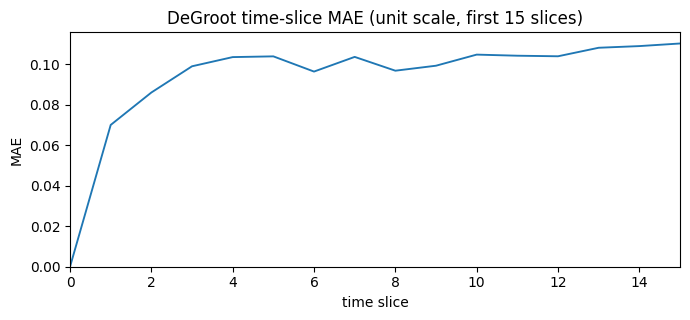

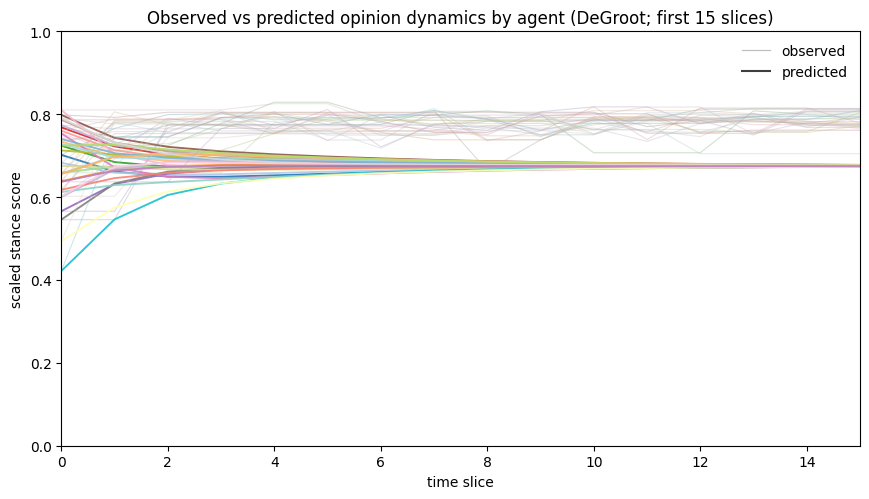

In [5]:
best = res.iloc[0].to_dict()
print('Best:', best)
out = run_timeslice_degroot(data, alpha=float(best['alpha']), predictor=FIRST_POST_PREDICTOR, rng_seed=PARAMS['predictor_rng_seed'])

all_df = pd.DataFrame(out['records']).sort_values(['agent', 'time_slice']).reset_index(drop=True)
df = all_df.copy()
comparison_start = int(df['time_slice'].min()) if not df.empty else 0

df['abs_err'] = (df['pred_unit'] - df['obs_unit']).abs()
met = {
    'mae': float(df['abs_err'].mean()) if not df.empty else np.nan,
    'rmse': float(np.sqrt(np.mean((df['pred_unit'] - df['obs_unit']) ** 2))) if not df.empty else np.nan,
    'r2': float(r2_score(df['obs_unit'], df['pred_unit'])) if len(df) > 1 and df['obs_unit'].nunique() > 1 else np.nan,
}
print('Metrics on unit scale [0, 1]:', met)
print('Using constant alpha =', float(best['alpha']))
print('First-post predictor =', FIRST_POST_PREDICTOR['basis'], FIRST_POST_PREDICTOR['model_name'])
print('Comparisons start at time_slice =', comparison_start)
print('Scaling: unit = (stance_score + 1) / 2, inverse = 2 * unit - 1')

init_df = out['init_df']
print('Initialization sources:')
display(init_df['source'].value_counts().rename_axis('source').reset_index(name='count'))

slice0_df = df[df['time_slice'] == 0].copy()
if not slice0_df.empty:
    slice0_max_gap = float((slice0_df['pred_unit'] - slice0_df['obs_unit']).abs().max())
    slice0_mean_gap = float((slice0_df['pred_unit'] - slice0_df['obs_unit']).abs().mean())
    print('Slice-0 agreement check:', {'max_abs_gap': slice0_max_gap, 'mean_abs_gap': slice0_mean_gap})

err_t = df.groupby('time_slice', as_index=False)['abs_err'].mean()
# restrict to the first 15 slices only
err_t = err_t[err_t['time_slice'] <= 15]
plt.figure(figsize=(7.0, 3.3))
plt.plot(err_t['time_slice'], err_t['abs_err'], color='tab:blue', linewidth=1.35)
plt.title('DeGroot time-slice MAE (unit scale, first 15 slices)')
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.ylim(0.0, max(0.05, float(err_t['abs_err'].max()) * 1.05))
plt.xlim(0, 15)
plt.tight_layout()
plt.show()

from matplotlib.lines import Line2D

agent_order = sorted(df['agent'].unique(), key=numeric_agent_key)
palette = np.array(list(plt.cm.tab20.colors) + list(plt.cm.Set3.colors) + list(plt.cm.Dark2.colors))[:len(agent_order)]

plt.figure(figsize=(8.8, 5.1))
for i, agent in enumerate(agent_order):
    dfa = df[df['agent'] == agent].sort_values('time_slice')
    dfa = dfa[dfa['time_slice'] <= 15]
    base_rgb = np.asarray(palette[i][:3], dtype=float)
    obs_rgb = 0.55 * np.array([0.72, 0.72, 0.72]) + 0.45 * base_rgb
    plt.plot(
        dfa['time_slice'],
        dfa['obs_unit'],
        color=(*obs_rgb, 0.35),
        linewidth=0.8,
        solid_capstyle='round',
    )
    plt.plot(
        dfa['time_slice'],
        dfa['pred_unit'],
        color=(*base_rgb, 0.9),
        linewidth=1.35,
        solid_capstyle='round',
    )

legend_handles = [
    Line2D([0], [0], color=(0.45, 0.45, 0.45, 0.45), linewidth=0.9, label='observed'),
    Line2D([0], [0], color=(0.2, 0.2, 0.2, 0.95), linewidth=1.5, label='predicted'),
]
plt.title('Observed vs predicted opinion dynamics by agent (DeGroot; first 15 slices)')
plt.xlabel('time slice')
plt.ylabel('scaled stance score')
plt.ylim(0.0, 1.0)
plt.xlim(0, 15)
plt.legend(handles=legend_handles, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

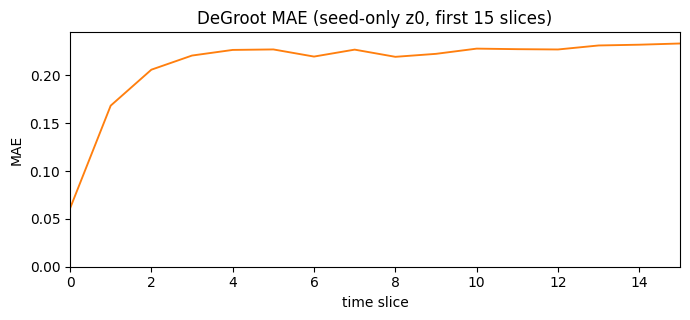

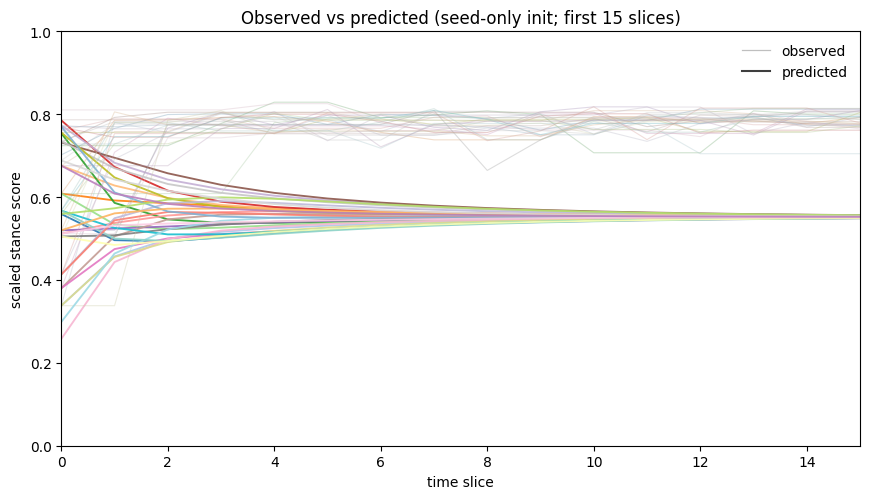

In [6]:
# Init opinion based output

seed_profiles = initial_seed_profiles(data['obs_by_agent_slice'], data['agent_ids'])
z0_direct = {a: float(to_unit_interval(seed_profiles[a])) for a in data['agent_ids']}

def run_degroot_with_fixed_z0(data, z0_dict, alpha):
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_static(preds, agent_ids)

    z = np.array([z0_dict[a] for a in agent_ids], dtype=float)
    effective_obs_unit = {agent: float(z0_dict[agent]) for agent in agent_ids}
    effective_obs_ss = {agent: float(seed_profiles[agent]) for agent in agent_ids}
    self_posts_by_agent_slice = build_self_post_lookup(RUN_DIR)
    records = []

    for time_slice in range(0, data['max_time_slice'] + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(alpha * z + (1.0 - alpha) * social, 0.0, 1.0)
        for agent in agent_ids:
            self_post_map = self_posts_by_agent_slice.get(agent, {})
            if time_slice in self_post_map:
                obs_ss = float(self_post_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
                effective_obs_ss[agent] = obs_ss
                effective_obs_unit[agent] = obs_unit
            else:
                obs_ss = effective_obs_ss[agent]
                obs_unit = effective_obs_unit[agent]
            pred_unit = float(z[idx[agent]])
            pred_ss = float(from_unit_interval(pred_unit))
            records.append({
                'time_slice': int(time_slice),
                'agent': agent,
                'pred_unit': pred_unit,
                'obs_unit': obs_unit,
                'pred_ss': pred_ss,
                'obs_ss': obs_ss,
            })
    return records

alpha = float(best['alpha'])
seed_only_records = run_degroot_with_fixed_z0(data, z0_direct, alpha)
seed_df = pd.DataFrame(seed_only_records).sort_values(['agent','time_slice']).reset_index(drop=True)
seed_df['abs_err'] = (seed_df['pred_unit'] - seed_df['obs_unit']).abs()

err_t2 = seed_df.groupby('time_slice', as_index=False)['abs_err'].mean()
err_t2 = err_t2[err_t2['time_slice'] <= 15]
plt.figure(figsize=(7.0,3.3))
plt.plot(err_t2['time_slice'], err_t2['abs_err'], color='tab:orange', linewidth=1.35)
plt.title('DeGroot MAE (seed-only z0, first 15 slices)')
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.ylim(0.0, max(0.05, float(err_t2['abs_err'].max())*1.05))
plt.xlim(0,15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.8,5.1))
for i, agent in enumerate(agent_order):
    dfa = seed_df[seed_df['agent']==agent].sort_values('time_slice')
    dfa = dfa[dfa['time_slice'] <= 15]
    base_rgb = np.asarray(palette[i][:3], dtype=float)
    obs_rgb = 0.55 * np.array([0.72,0.72,0.72]) + 0.45*base_rgb
    plt.plot(dfa['time_slice'], dfa['obs_unit'], color=(*obs_rgb,0.35), linewidth=0.8, solid_capstyle='round')
    plt.plot(dfa['time_slice'], dfa['pred_unit'], color=(*base_rgb,0.9), linewidth=1.35, solid_capstyle='round')

plt.title('Observed vs predicted (seed-only init; first 15 slices)')
plt.xlabel('time slice')
plt.ylabel('scaled stance score')
plt.ylim(0.0,1.0)
plt.xlim(0,15)
plt.legend(handles=legend_handles, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()